In [ ]:
import os
import sys

from loguru import logger
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../.."))
from spatial_nav.CAN_IMP.visualize3D import visualize_trajectory_3D
from spatial_nav.CAN_IMP.QAN3D import Torus3DQAN
from spatial_nav.CAN_IMP.torus3D_manifold import Torus3D

import matplotlib.pyplot as plt
from spatial_nav.CAN_IMP.visualize3D import visualize_can_state_3d

qan = Torus3DQAN(spacing=0.3, alpha=0.8, sigma=1.5, b=1, beta=125)
short_traj = qan.make_trajectory(n_steps=200)
decoded = qan.simulate(short_traj)
fig, _ = visualize_can_state_3d(qan.cans[0])
plt.show()

S = qan.cans[0].S
print(f"State range: [{S.min():.3f}, {S.max():.3f}]")
print(f"Number of neurons above 50% peak: {np.sum(S > 0.5 * S.max())}")
print(f"Total neurons: {len(S)}")



AttributeError: 'CAN3D' object has no attribute 'W_local'

In [ ]:
logger.info("Building TorusT3QAN with spacing=0.3 ...")
t0 = time.time()
manifold = Torus3D()
qan = Torus3DQAN(spacing=0.5, alpha=0.8, sigma=1.5, b=1.6)
logger.info(f"Built in {time.time()-t0:.1f}s | "
            f"Neurons: {qan.cans[0].neurons_coordinates.shape[0]} | "
            f"6 CANs total")

2026-05-03 22:36:49.472 | INFO     | __main__:<module>:1 - Building TorusT3QAN with spacing=0.3 ...
2026-05-03 22:36:51.725 | INFO     | __main__:<module>:5 - Built in 2.2s | Neurons: 2197 | 6 CANs total


In [ ]:
logger.info("Generating trajectory ...")
trajectory = qan.make_trajectory(n_steps=1000)
logger.info(f"Trajectory shape: {trajectory.shape}")

2026-05-03 22:36:51.867 | INFO     | __main__:<module>:1 - Generating trajectory ...
2026-05-03 22:36:51.868 | INFO     | __main__:<module>:3 - Trajectory shape: (1000, 3)


In [ ]:
logger.info("Simulating ...")
t0 = time.time()
decoded = qan.simulate(trajectory)
elapsed = time.time() - t0
logger.info(f"Simulation done in {elapsed:.1f}s | "
            f"{elapsed/len(trajectory)*1000:.2f}ms per timestep")

2026-05-03 22:36:52.031 | INFO     | __main__:<module>:1 - Simulating ...
2026-05-03 22:36:56.600 | INFO     | __main__:<module>:5 - Simulation done in 4.6s | 4.57ms per timestep


In [ ]:
n_unique = np.unique(decoded, axis=0).shape[0]
logger.info(f"Unique decoded positions: {n_unique} / {len(trajectory)}")
logger.info(f"Decoded range: min={decoded.min(axis=0)}, max={decoded.max(axis=0)}")

2026-05-03 22:36:56.623 | INFO     | __main__:<module>:2 - Unique decoded positions: 1000 / 1000
2026-05-03 22:36:56.624 | INFO     | __main__:<module>:3 - Decoded range: min=[0. 0. 0.], max=[6.20753434 6.27494031 6.26771597]


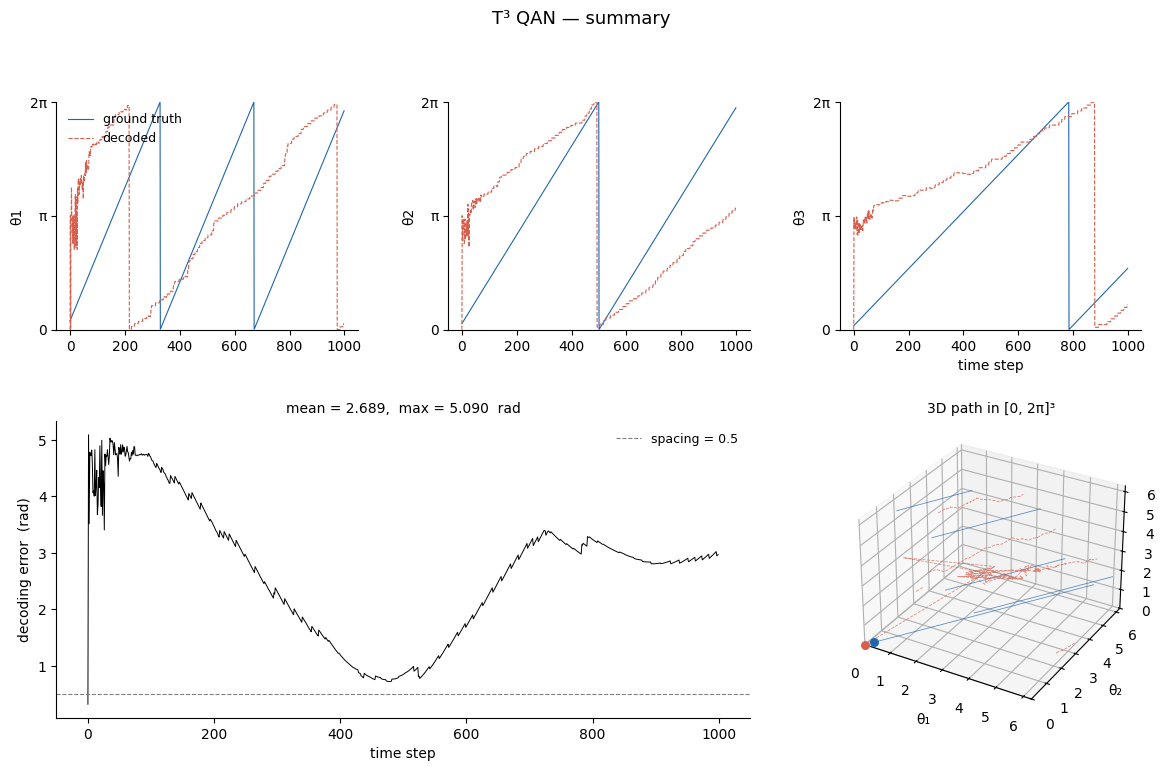

In [ ]:
import matplotlib.pyplot as plt
from spatial_nav.CAN_IMP.visualize3D import visualize_qan_summary

fig, _ = visualize_qan_summary(trajectory, decoded, qan, title="T³ QAN — summary")
plt.show()
